# g-方法教程

### 戒烟让人长胖多少

戒烟的人体重会增加，这是常识。增加多少？直接比较戒烟者和继续吸烟者并不可靠，戒烟的人平均年龄更大、烟龄更长、基线体重也不同。

这是 Hernán and Robins 的教材 *Causal Inference: What If* 贯穿第二部分的例子，数据来自美国的 NHEFS 随访调查，随 StatsPAI 自带。流行病学里处理这类问题的一组方法统称 **g-方法**，包括逆概率加权、标准化（g-公式）和 g-估计。它们与经济学里的加权和回归调整是同一件事的不同说法，但在一个场景下有回归做不到的本领，那就是**随时间变化的混淆**。

本教程先在 NHEFS 上把三种方法各做一遍，每种都先手工算、再用一行函数调用，然后加上双重稳健估计和敏感性分析。最后用一个模拟说明时变混淆为什么会让普通回归失效。全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 问题与假设 | 可交换性、正值性、一致性 |
| 2 | 数据 | NHEFS，混淆变量的选择 |
| 3 | 粗比较 | 为什么不可信 |
| 4 | 逆概率加权 | 构造一个没有混淆的「伪总体」 |
| 5 | 标准化 | 用结果模型预测每个人在两种处理下的结果 |
| 6 | g-估计 | 第三条路 |
| 7 | 双重稳健与 TMLE | 两个模型只要对一个 |
| 8 | 把结果放在一起 | 与教材的数字对照 |
| 9 | 敏感性分析 | E 值 |
| 10 | 时变混淆 | 回归为什么失效，g-方法为什么不会 |
| 11 | 小结 | 一份清单 |

## 1. 问题与假设

记 $A$ 为是否戒烟，$Y^{a=1}$ 和 $Y^{a=0}$ 为每个人在戒烟和不戒烟两种情形下的体重变化（流行病学习惯用上标表示潜在结果），$L$ 为基线特征。目标是平均因果效应

$$
E\big[Y^{a=1}\big] - E\big[Y^{a=0}\big].
$$

这是「所有人都戒烟」与「所有人都不戒烟」两种假想情形下平均体重变化的差。

识别它需要三个条件。

| 条件 | 流行病学的叫法 | 含义 | 经济学里对应的说法 |
| --- | --- | --- | --- |
| $Y^{a} \perp A \mid L$ | 条件可交换性 | 给定 $L$，戒烟与否与潜在结果无关 | 条件独立、无混淆 |
| $0 < P(A = 1 \mid L) < 1$ | 正值性 | 每一类人里都既有戒烟的也有不戒烟的 | 重叠、共同支撑 |
| $A = a \Rightarrow Y = Y^{a}$ | 一致性 | 处理的定义足够明确，观测到的结果就是对应的潜在结果 | SUTVA 的一部分 |

第一条无法用数据检验，靠的是对混淆结构的专业判断。第三条提醒我们，「戒烟」要有清楚的定义，否则「如果所有人都戒烟」这个假想情形本身就含糊不清。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 2. 数据

`sp.datasets.nhefs(complete_case=True)` 返回体重变化有记录的 1,566 人，他们在 1971 年前后的基线调查时都是吸烟者。

| 变量 | 含义 | 角色 |
| --- | --- | --- |
| `qsmk` | 基线到 1982 年之间是否戒烟 | **处理** |
| `wt82_71` | 1982 年体重减去 1971 年体重（公斤） | **结果** |
| `sex`, `race`, `age` | 性别，种族，年龄 | 混淆变量 |
| `education` | 受教育程度（5 档） | 混淆变量 |
| `smokeintensity`, `smokeyrs` | 每天吸烟支数，烟龄 | 混淆变量 |
| `exercise`, `active` | 锻炼频率，日常活动量（各 3 档） | 混淆变量 |
| `wt71` | 1971 年基线体重（公斤） | 混淆变量 |

教材假设条件于这 9 个基线变量之后可交换性成立。模型的设定也照教材，分类变量用虚拟变量，四个连续变量加入平方项。

In [2]:
df = sp.datasets.nhefs(complete_case=True)

CATEGORICAL = ["sex", "race", "education", "exercise", "active"]
CONTINUOUS = ["age", "smokeintensity", "smokeyrs", "wt71"]

design = df.copy()
for c in CONTINUOUS:
    design[f"{c}2"] = design[c] ** 2                               # 连续变量的平方项
design = pd.get_dummies(design, columns=CATEGORICAL, drop_first=True)

dummy_cols = [c for c in design.columns if any(c.startswith(p + "_") for p in CATEGORICAL)]
covs = dummy_cols + CONTINUOUS + [f"{c}2" for c in CONTINUOUS]
design[covs] = design[covs].astype(float)

print(f"样本量 {len(df)}，其中戒烟者 {int(df['qsmk'].sum())} 人（{df['qsmk'].mean():.1%}）")
print(f"混淆变量展开后共 {len(covs)} 列")

样本量 1566，其中戒烟者 403 人（25.7%）
混淆变量展开后共 18 列


## 3. 粗比较

In [3]:
crude = df.loc[df["qsmk"] == 1, "wt82_71"].mean() - df.loc[df["qsmk"] == 0, "wt82_71"].mean()

print(df.groupby("qsmk")[["wt82_71", "age", "wt71", "smokeintensity", "smokeyrs", "sex"]].mean().round(2))
print(f"\n粗差异: 戒烟者比未戒烟者多增重 {crude:.2f} 公斤")

      wt82_71    age   wt71  smokeintensity  smokeyrs   sex
qsmk                                                       
0.0      1.98  42.79  70.30           21.19     24.09  0.53
1.0      4.53  46.17  72.35           18.60     26.03  0.45

粗差异: 戒烟者比未戒烟者多增重 2.54 公斤


戒烟者平均多增重 2.5 公斤。但两组人并不可比。戒烟者平均大 3 岁多，烟龄更长，每天吸得少一些，基线体重高 2 公斤，男性比例更高。这些特征本身就影响体重的变化，比如年龄越大体重越不容易增加。

如果戒烟者因为年龄大而本来增重较少，粗比较就会**低估**戒烟的效应。下面三种方法用不同的方式去掉这些差别。

## 4. 逆概率加权

逆概率加权的思路是给每个人一个权重，使加权之后的样本里，戒烟与否和基线特征不再相关。这个加权后的样本叫**伪总体**（pseudo-population）。在伪总体里没有混淆，直接比较两组均值就行。

每个人的权重是他实际接受的那种处理的概率的倒数。

$$
W_i = \frac{1}{P(A = A_i \mid L_i)} =
\begin{cases} 1 / e(L_i) & \text{戒烟者} \\ 1 / \big(1 - e(L_i)\big) & \text{未戒烟者} \end{cases}
$$

其中 $e(L) = P(A = 1 \mid L)$ 是倾向得分。直观上，一个「按特征看不太可能戒烟、实际却戒了」的人很稀有，他要代表很多和他相似但没戒烟的人，所以权重大。

### 手工做一遍

In [4]:
# 第一步，用 logit 模型估计每个人戒烟的概率
ps_model = sp.logit("qsmk ~ " + " + ".join(covs), data=design)
ps = np.asarray(ps_model.predict(design))

# 第二步，算权重
design["w"] = np.where(design["qsmk"] == 1, 1 / ps, 1 / (1 - ps))

print(f"倾向得分的范围: {ps.min():.3f} 到 {ps.max():.3f}")
print(f"权重: 均值 {design['w'].mean():.2f}，最小 {design['w'].min():.2f}，最大 {design['w'].max():.2f}")

倾向得分的范围: 0.051 到 0.777
权重: 均值 2.00，最小 1.05，最大 16.70


In [5]:
# 加权之后，基线特征在两组之间是否平衡
def weighted_means(frame, cols, weight):
    return frame.groupby("qsmk").apply(lambda g: pd.Series({c: np.average(g[c], weights=g[weight]) for c in cols}))

check = ["age", "wt71", "smokeintensity", "smokeyrs"]
print("加权前:")
print(design.groupby("qsmk")[check].mean().round(2))
print("\n加权后（伪总体）:")
print(weighted_means(design, check, "w").round(2))

加权前:
        age   wt71  smokeintensity  smokeyrs
qsmk                                        
0.0   42.79  70.30           21.19     24.09
1.0   46.17  72.35           18.60     26.03

加权后（伪总体）:
        age   wt71  smokeintensity  smokeyrs
qsmk                                        
0.0   43.62  70.80           20.49     24.58
1.0   43.69  70.66           20.21     24.54


加权之后，两组在这几个基线特征上的均值几乎相同。伪总体里戒烟与否和这些特征无关了。

倾向得分最小 0.05、最大 0.78，没有贴近 0 或 1，权重最大也只有十几。正值性没有明显的问题。

第三步，在伪总体里比较两组。这等价于用权重做一个只含处理变量的加权回归，流行病学里称为**边际结构模型**（marginal structural model）。

In [6]:
msm = sp.regress("wt82_71 ~ qsmk", data=design, weights="w", robust="hc1")
print(f"手工 IPW: {msm.params['qsmk']:.3f} 公斤  (稳健 se {msm.std_errors['qsmk']:.3f})")

手工 IPW: 3.441 公斤  (稳健 se 0.526)


### 一行代码

`sp.ipw` 把上面三步合在一起。标准误用三明治公式，并且考虑了倾向得分是估计出来的这一事实。

In [7]:
ipw = sp.ipw(design, y="wt82_71", treat="qsmk", covariates=covs, estimand="ATE", se_method="sandwich")
print(f"sp.ipw: {ipw.estimate:.3f} 公斤  (se {ipw.se:.3f})   95% CI [{ipw.ci[0]:.2f}, {ipw.ci[1]:.2f}]")

sp.ipw: 3.441 公斤  (se 0.487)   95% CI [2.49, 4.40]


点估计与手工算的一致。标准误比手工加权回归的稳健标准误小一些。把估计出来的权重当成已知的固定数，会高估不确定性，所以那个稳健标准误是保守的。

调整之后效应从 2.5 公斤上升到 3.4 公斤，粗比较确实低估了。

## 5. 标准化

标准化走的是另一条路。它不对处理建模，而是对**结果**建模。

1. 拟合一个结果模型 $E[Y \mid A, L]$。
2. 用这个模型预测**每一个人**在 $A = 1$ 时的结果，再预测每一个人在 $A = 0$ 时的结果。
3. 两组预测值各自对全样本取平均，相减。

$$
\hat E\big[Y^{a}\big] = \frac{1}{n} \sum_{i=1}^{n} \hat E\big[Y \mid A = a,\, L = L_i\big].
$$

这个公式叫 **g-公式**。它的意思是，先在每一类人内部比较，再按这类人在总体中的比例加权平均。

### 手工做一遍

In [8]:
outcome_model = sp.regress("wt82_71 ~ qsmk + " + " + ".join(covs), data=design)

everyone_quits = outcome_model.predict(design.assign(qsmk=1.0))     # 把所有人都设成戒烟
nobody_quits = outcome_model.predict(design.assign(qsmk=0.0))       # 把所有人都设成不戒烟

print(f"所有人都戒烟时的平均增重   : {everyone_quits.mean():.3f} 公斤")
print(f"所有人都不戒烟时的平均增重 : {nobody_quits.mean():.3f} 公斤")
print(f"手工标准化的效应           : {everyone_quits.mean() - nobody_quits.mean():.3f} 公斤")

所有人都戒烟时的平均增重   : 5.210 公斤
所有人都不戒烟时的平均增重 : 1.747 公斤
手工标准化的效应           : 3.463 公斤


这里的结果模型是线性的，没有处理与协变量的交互项，所以标准化的结果恰好等于回归里 `qsmk` 的系数。一旦模型里有交互项或者是非线性的（比如结果是二值的，用 logit），两者就不再相等，必须走「预测再平均」这一步。这是标准化比读回归系数更一般的地方。

### 一行代码

`sp.g_computation` 做同样的事，标准误来自 bootstrap。

In [9]:
gcomp = sp.g_computation(design, y="wt82_71", treat="qsmk", covariates=covs, n_boot=500, seed=42)
print(f"sp.g_computation: {gcomp.estimate:.3f} 公斤  (se {gcomp.se:.3f})   95% CI [{gcomp.ci[0]:.2f}, {gcomp.ci[1]:.2f}]")

sp.g_computation: 3.463 公斤  (se 0.458)   95% CI [2.57, 4.43]


### 两种方法的关系

| | 逆概率加权 | 标准化 |
| --- | --- | --- |
| 建模的对象 | 处理 $P(A \mid L)$ | 结果 $E[Y \mid A, L]$ |
| 模型设错的后果 | 倾向得分模型错则有偏 | 结果模型错则有偏 |
| 重叠差的时候 | 权重极端，方差大，问题看得见 | 靠模型外推，问题看不见 |

两个模型都对的时候，两种方法估计的是同一个量。它们用了不同的模型假设，结果一致是一个令人安心的信号，结果不一致则说明至少有一个模型有问题。

## 6. g-估计

g-估计是第三条路，对应**结构嵌套模型**。它的逻辑是反过来的。

假设戒烟的效应是某个数 $\psi$。那么从每个人的观测结果里减去 $\psi \cdot A$，得到的就是他不戒烟时的潜在结果 $Y^{a=0}$。在可交换性成立时，这个潜在结果给定 $L$ 之后应该与实际是否戒烟**无关**。于是去找那个使「$Y - \psi A$ 与 $A$ 在给定 $L$ 后不相关」的 $\psi$。

In [10]:
gest = sp.g_estimation(
    design, y="wt82_71", treatments=["qsmk"], covariates_by_stage=[covs],
    n_bootstrap=300, random_state=42,
)
print(f"sp.g_estimation: {gest.estimate:.3f} 公斤  (se {gest.se:.3f})   95% CI [{gest.ci[0]:.2f}, {gest.ci[1]:.2f}]")

sp.g_estimation: 3.461 公斤  (se 0.459)   95% CI [2.56, 4.36]


单一时点的问题里 g-估计用得不多，它的优势在多个时点的序贯处理里才显出来。这里把它列出来，是为了看到三种方法殊途同归。

## 7. 双重稳健与 TMLE

逆概率加权依赖处理模型，标准化依赖结果模型。双重稳健估计量把两个模型都用上，**只要其中一个设定正确，估计就是一致的**。

- **AIPW**（增广逆概率加权）在标准化的预测值上加一个用倾向得分加权的残差修正项。
- **TMLE**（目标最大似然估计）先拟合结果模型，再用倾向得分对它做一次小的「定向」更新，使最终的估计量满足有效影响函数的估计方程。它的预测值始终落在结果的取值范围内，结果是二值或有界时比 AIPW 更稳定。

两者都可以搭配灵活的机器学习模型，并通过交叉拟合保证推断仍然有效。

In [11]:
aipw = sp.aipw(design, y="wt82_71", treat="qsmk", covariates=covs)
tmle = sp.tmle(design, y="wt82_71", treat="qsmk", covariates=covs)

print(f"sp.aipw: {aipw.estimate:.3f} 公斤  (se {aipw.se:.3f})   95% CI [{aipw.ci[0]:.2f}, {aipw.ci[1]:.2f}]")
print(f"sp.tmle: {tmle.estimate:.3f} 公斤  (se {tmle.se:.3f})   95% CI [{tmle.ci[0]:.2f}, {tmle.ci[1]:.2f}]")

sp.aipw: 3.551 公斤  (se 0.517)   95% CI [2.54, 4.56]
sp.tmle: 3.443 公斤  (se 0.460)   95% CI [2.54, 4.34]


## 8. 把结果放在一起

教材报告的数字是，粗差异 2.5 公斤，逆概率加权 3.4 公斤（95% 置信区间 2.4 到 4.5），标准化 3.5 公斤，g-估计 3.4 公斤。

In [12]:
summary = pd.DataFrame(
    [
        ("crude difference", crude, np.nan, np.nan, np.nan),
        ("IP weighting", ipw.estimate, ipw.se, *ipw.ci),
        ("standardization (g-formula)", gcomp.estimate, gcomp.se, *gcomp.ci),
        ("g-estimation", gest.estimate, gest.se, *gest.ci),
        ("AIPW (doubly robust)", aipw.estimate, aipw.se, *aipw.ci),
        ("TMLE (doubly robust)", tmle.estimate, tmle.se, *tmle.ci),
    ],
    columns=["method", "estimate (kg)", "se", "ci_lower", "ci_upper"],
)
summary.round(2)

,method,estimate (kg),se,ci_lower,ci_upper
0,crude difference,2.54,NaN,NaN,NaN
1,IP weighting,3.44,0.49,2.49,4.40
2,standardization (g-formula),3.46,0.46,2.57,4.43
3,g-estimation,3.46,0.46,2.56,4.36
4,AIPW (doubly robust),3.55,0.52,2.54,4.56
5,TMLE (doubly robust),3.44,0.46,2.54,4.34


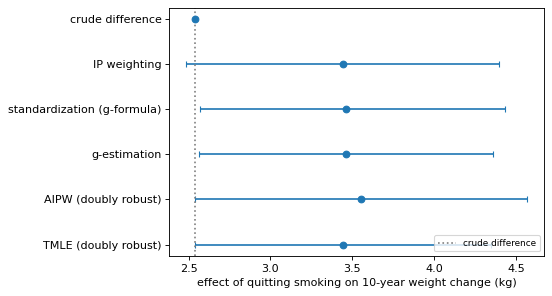

In [13]:
plot_df = summary.iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.errorbar(
    plot_df["estimate (kg)"], plot_df["method"],
    xerr=[plot_df["estimate (kg)"] - plot_df["ci_lower"].fillna(plot_df["estimate (kg)"]),
          plot_df["ci_upper"].fillna(plot_df["estimate (kg)"]) - plot_df["estimate (kg)"]],
    fmt="o", capsize=3,
)
ax.axvline(crude, color="grey", ls=":", label="crude difference")
ax.set_xlabel("effect of quitting smoking on 10-year weight change (kg)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

五种调整方法给出 3.4 到 3.6 公斤的估计，置信区间高度重合，与教材的数字一致。它们用了不同的模型，却得到几乎相同的答案。

结论是，在这 9 个基线变量足以控制混淆的前提下，戒烟使十年间的体重平均多增加约 3.5 公斤。

## 9. 敏感性分析

「在这 9 个变量足以控制混淆的前提下」是一个很强的前提。如果存在没有测量的混淆因素，结论还站得住吗？

VanderWeele and Ding (2017) 提出的 **E 值**把这个问题量化了。它的定义是，一个未测量的混淆因素至少要与处理和结果**各自**有多强的关联（用风险比表示），才能把观测到的关联完全解释掉。E 值越大，结论越稳健。

E 值是为风险比设计的。换一个二值结果来演示，看戒烟与随访期内死亡的关联。下面用的是未经调整的粗风险比，只为说明 E 值怎么算、怎么读。

In [14]:
full = sp.datasets.nhefs()
risk_quit = full.loc[full["qsmk"] == 1, "death"].mean()
risk_cont = full.loc[full["qsmk"] == 0, "death"].mean()
rr = risk_quit / risk_cont

ev = sp.evalue(estimate=float(rr), measure="RR")
print(f"戒烟者的死亡风险 {risk_quit:.3f}，未戒烟者 {risk_cont:.3f}，粗风险比 {rr:.2f}")
print(f"E 值 = {ev['evalue_estimate']:.2f}\n")
print(ev["interpretation"])

戒烟者的死亡风险 0.238，未戒烟者 0.180，粗风险比 1.33
E 值 = 1.98

E-value for point estimate: 1.98
The observed association is somewhat robust to unmeasured confounding.
An unmeasured confounder would need to be associated with both treatment and outcome by a risk ratio of at least 1.98 (each, beyond the measured covariates) to move the point estimate to the null.


粗风险比是 1.33，戒烟者的死亡风险反而更高。这显然不是因果效应。第 3 节已经看到戒烟者年龄更大，而年龄与死亡的关联非常强。

E 值是 1.98。一个与戒烟和死亡各有 2 倍左右风险比关联的混淆因素就足以解释掉这个关联。年龄轻而易举就能达到这个强度，所以这个粗关联完全不可信。E 值在这里给出了一个与常识相符的判断。

在正式分析里，E 值应该用在**调整之后**的估计上，并且对置信区间靠近 1 的那一端也算一个。它回答的是「剩余的未测量混淆要多强」。对连续结果的线性回归，对应的工具是 `sp.sensemakr`，见 `tutorial_matching_lalonde.ipynb`。

## 10. 时变混淆

到这里为止，g-方法和回归调整给出的答案没有区别。它们真正不可替代的地方在于**处理随时间变化**的情形。

设想病人分两次就诊。每次医生根据当时的病情指标 $L$ 决定是否用药 $A$。

- 第一次用药 $A_0$ 会改变第二次就诊时的病情 $L_1$。
- $L_1$ 又影响第二次是否用药 $A_1$，同时直接影响最终结果 $Y$。

于是 $L_1$ 有双重身份。它是 $A_1 \to Y$ 的**混淆变量**，必须控制。它又是 $A_0 \to Y$ 的**中介变量**，控制了它就把 $A_0$ 通过 $L_1$ 起作用的那部分效应挡掉了。

回归在这里进退两难。不控制 $L_1$，$A_1$ 的效应被混淆。控制 $L_1$，$A_0$ 的效应被低估。**没有任何一个回归设定是对的**。

下面的模拟里，「两次都用药」对比「两次都不用药」的真实效应是 6。其中 $A_0$ 的直接效应是 2，通过 $L_1$ 的间接效应是 1，$A_1$ 的效应是 3。

In [15]:
rng = np.random.default_rng(0)
n = 5000

L0 = rng.normal(size=n)                                             # 基线病情
A0 = rng.binomial(1, 1 / (1 + np.exp(-0.5 * L0)))                   # 第一次用药，取决于 L0
L1 = L0 + 0.5 * A0 + rng.normal(scale=0.5, size=n)                  # 第二次病情，受 A0 影响
A1 = rng.binomial(1, 1 / (1 + np.exp(-(0.3 * L1 + 0.5 * A0))))      # 第二次用药，取决于 L1 和 A0
Y = 2 * A0 + 3 * A1 + L0 + 2 * L1 + rng.normal(scale=0.5, size=n)   # 结果

tv = pd.DataFrame({"id": np.arange(n), "L0": L0, "A0": A0, "L1": L1, "A1": A1, "Y": Y})

rows = []
for label, formula in [
    ("no adjustment", "Y ~ A0 + A1"),
    ("adjust for L0 only", "Y ~ A0 + A1 + L0"),
    ("adjust for L0 and L1", "Y ~ A0 + A1 + L0 + L1"),
]:
    fit = sp.regress(formula, data=tv)
    rows.append((label, fit.params["A0"], fit.params["A1"], fit.params["A0"] + fit.params["A1"]))

print("真实效应: A0 的总效应 = 3，A1 的效应 = 3，合计 = 6")
pd.DataFrame(rows, columns=["OLS specification", "coef A0", "coef A1", "A0 + A1"]).round(3)

真实效应: A0 的总效应 = 3，A1 的效应 = 3，合计 = 6


,OLS specification,coef A0,coef A1,A0 + A1
0,no adjustment,4.250,3.924,8.174
1,adjust for L0 only,2.988,3.180,6.167
2,adjust for L0 and L1,1.987,3.011,4.998


三个回归都不对。

- 不做调整时两个系数都严重偏高。
- 控制 $L_0$ 和 $L_1$ 时，$A_1$ 的系数是对的，$A_0$ 的系数只有 2。它只捕捉到了直接效应，通过 $L_1$ 的间接效应被挡掉了，合计只有 5。
- 只控制 $L_0$ 时合计接近 6，但那是巧合。$A_1$ 的系数仍然被 $L_1$ 中没有被 $L_0$ 解释的部分混淆，偏高了一些。

### g-公式

g-公式按时间顺序处理这个问题。它不是在一个回归里同时「控制」所有变量，而是模拟在给定的用药策略下，$L_1$ 会怎样随 $A_0$ 变化，$Y$ 又会怎样随之变化。`sp.gformula.ice` 用迭代条件期望实现这一点。

In [16]:
def strategy_mean(strategy):
    return sp.gformula.ice(
        data=tv, id_col="id", time_col=None,
        treatment_cols=["A0", "A1"], confounder_cols=[["L0"], ["L1"]],
        outcome_col="Y", treatment_strategy=strategy,
    ).value

always, never = strategy_mean([1, 1]), strategy_mean([0, 0])
print(f"g-公式: 两次都用药 {always:.3f}，两次都不用药 {never:.3f}，差 = {always - never:.3f}   (真值 6)")

g-公式: 两次都用药 6.009，两次都不用药 -0.014，差 = 6.023   (真值 6)


### 边际结构模型

逆概率加权同样可以按时间顺序进行。每个时点算一个权重，分母是「给定到那时为止的全部历史，实际接受这种处理的概率」，再把各时点的权重乘起来。实践中使用**稳定权重**，分子换成只依赖过去处理的概率，可以大幅降低权重的波动。

$$
SW_i = \prod_{t=0}^{1} \frac{P(A_t = A_{it} \mid \bar A_{i,t-1})}{P(A_t = A_{it} \mid \bar A_{i,t-1},\, \bar L_{it})}.
$$

在加权后的伪总体里，每个时点的用药都与此前的病情无关，于是一个只含 $A_0$ 和 $A_1$ 的回归就能给出正确答案。

In [17]:
def prob_of_observed(model, frame, treatment):
    p = np.asarray(model.predict(frame))
    return np.where(frame[treatment] == 1, p, 1 - p)

# 分母：给定病情历史的处理概率
den0 = prob_of_observed(sp.logit("A0 ~ L0", data=tv), tv, "A0")
den1 = prob_of_observed(sp.logit("A1 ~ A0 + L0 + L1", data=tv), tv, "A1")
# 分子：只依赖过去处理的概率
num0 = np.where(tv["A0"] == 1, tv["A0"].mean(), 1 - tv["A0"].mean())
num1 = prob_of_observed(sp.logit("A1 ~ A0", data=tv), tv, "A1")

tv["sw"] = (num0 / den0) * (num1 / den1)
print(f"稳定权重: 均值 {tv['sw'].mean():.3f}，最大 {tv['sw'].max():.2f}")

msm_tv = sp.regress("Y ~ A0 + A1", data=tv, weights="sw", robust="hc1")
print(f"\n边际结构模型: A0 = {msm_tv.params['A0']:.3f}，A1 = {msm_tv.params['A1']:.3f}，合计 = {msm_tv.params['A0'] + msm_tv.params['A1']:.3f}   (真值 3、3、6)")

稳定权重: 均值 1.000，最大 3.93

边际结构模型: A0 = 3.030，A1 = 2.982，合计 = 6.013   (真值 3、3、6)


稳定权重的均值应该接近 1，这是检查权重模型的一个简单办法。

两种 g-方法都找回了真值，并且边际结构模型把 $A_0$ 的总效应 3（直接 2 加间接 1）完整地估了出来。

这就是 Robins 提出 g-方法的原因。慢性病治疗、长期用药、随时间调整的政策，只要处理会影响后来的混淆变量，就需要它们。`sp.msm` 和 `sp.gformula` 提供了多时点情形下的完整实现。

## 11. 小结

1. **写清楚因果问题**。比较的是哪两种干预，处理的定义是否明确，目标人群是谁。
2. **根据专业知识选混淆变量**，不要根据统计显著性。只放处理之前的变量。
3. **检查正值性**。看倾向得分和权重的分布，极端权重是警报。
4. **至少用两种依赖不同模型的方法**。逆概率加权（`sp.ipw`）依赖处理模型，标准化（`sp.g_computation`）依赖结果模型。
5. **再加一个双重稳健估计**（`sp.aipw`、`sp.tmle`）。
6. **做敏感性分析**（`sp.evalue`、`sp.sensemakr`）。
7. **处理随时间变化、且会影响后来的混淆变量时，不要用普通回归**。用 g-公式（`sp.gformula.ice`）或边际结构模型（`sp.msm`）。

延伸阅读见 `docs/guides/g_methods_ph.md` 和 `docs/guides/public_health.md`。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [18]:
keys = [
    "hernan2020causal",
    "robins1986new",
    "robins2000marginal",
    "cole2008constructing",
    "vanderlaan2006targeted",
    "vanderweele2017sensitivity",
]
print(sp.bibtex(keys))

@book{hernan2020causal,
  title={Causal Inference: What If},
  author={Hern{\'a}n, Miguel A. and Robins, James M.},
  publisher={Chapman \& Hall/CRC},
  year={2020},
  isbn={978-1-4200-7616-5},
  annote={No DOI: neither Chapman \& Hall/CRC nor the authors have registered this book with Crossref (searched by title and both authors, 2026-08-24). Cite by ISBN.}
}

@article{robins1986new,
  title={A new approach to causal inference in mortality studies with a sustained exposure period---application to control of the healthy worker survivor effect},
  author={Robins, James},
  journal={Mathematical Modelling},
  volume={7},
  number={9-12},
  pages={1393-1512},
  year={1986},
  doi={10.1016/0270-0255(86)90088-6}
}

@article{robins2000marginal,
  title={Marginal Structural Models and Causal Inference in Epidemiology},
  author={Robins, James M. and Hern{\'a}n, Miguel {\'A}ngel and Brumback, Babette},
  journal={Epidemiology},
  year={2000},
  doi={10.1097/00001648-200009000-00011}
}

@articl